# Retail Sales & Customer Analysis =

## Objective
Perform exploratory data analysis (EDA) using multiple related datasets without blindly merging them. Each dataset is analyzed independently and combined only when necessary.

## Strategy
- Orders → Core sales analysis
- Customers → Customer insights
- Products → Category & product performance
- Location → Regional analysis

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


# Load all files 

In [2]:

df_customers = pd.read_csv("Customers.csv", sep=';', encoding='latin1')
df_location = pd.read_csv("Location.csv", sep=';', encoding='latin1')
df_orders = pd.read_csv("Orders.csv", sep=';', encoding='latin1', on_bad_lines='skip')
df_products = pd.read_csv("Products.csv", sep=';', encoding='latin1')

## Clean Column Names

In [3]:
def clean_cols(df):
    df.columns = df.columns.str.strip().str.lower().str.replace(" ", "_")
    return df

df_customers = clean_cols(df_customers)
df_location = clean_cols(df_location)
df_orders = clean_cols(df_orders)
df_products = clean_cols(df_products)

## CHECK DATA

In [4]:
df_orders.head()
df_orders.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9994 entries, 0 to 9993
Data columns (total 13 columns):
 #   Column       Non-Null Count  Dtype 
---  ------       --------------  ----- 
 0   row_id       9994 non-null   int64 
 1   order_id     9994 non-null   object
 2   order_date   9994 non-null   object
 3   ship_date    9994 non-null   object
 4   ship_mode    9994 non-null   object
 5   customer_id  9994 non-null   object
 6   segment      9994 non-null   object
 7   postal_code  9994 non-null   int64 
 8   product_id   9994 non-null   object
 9   sales        9994 non-null   object
 10  quantity     9994 non-null   int64 
 11  discount     9994 non-null   object
 12  profit       9994 non-null   object
dtypes: int64(3), object(10)
memory usage: 1015.1+ KB


### Fix Data Types (Orders Table)

In [5]:
df_orders['order_date'] = pd.to_datetime(df_orders['order_date'], errors='coerce')

cols = ['sales','profit','discount','quantity']
for col in cols:
    df_orders[col] = pd.to_numeric(df_orders[col], errors='coerce')

In [6]:
df_orders.isnull().sum()

row_id            0
order_id          0
order_date     5952
ship_date         0
ship_mode         0
customer_id       0
segment           0
postal_code       0
product_id        0
sales          9866
quantity          0
discount       5196
profit         9915
dtype: int64

## BASIC CLEANING

In [7]:
df_orders = df_orders.dropna(subset=['order_date'])

In [8]:
df_orders['month'] = df_orders['order_date'].dt.month

In [9]:
df_orders['profit'] = df_orders['profit'].fillna(0)

In [10]:
df_orders['discount'] = df_orders['discount'].fillna(0)

In [11]:
df_orders.isnull().sum()

row_id            0
order_id          0
order_date        0
ship_date         0
ship_mode         0
customer_id       0
segment           0
postal_code       0
product_id        0
sales          3992
quantity          0
discount          0
profit            0
month             0
dtype: int64

In [12]:
df_orders = df_orders.drop_duplicates()
df_orders = df_orders.dropna(subset=['sales'])

In [13]:
df_orders[['sales','profit','quantity']].sum()

sales       9369.0
profit        87.0
quantity     178.0
dtype: float64

Missing values were handled by:
- Dropping rows with missing order_date to ensure accurate time-based analysis
- Filling missing profit and discount values with 0 to maintain data consistency

### Monthly Sales Trend

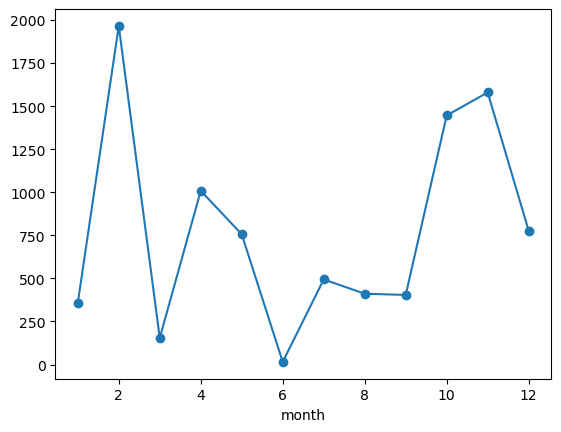

In [14]:
df_orders['month'] = df_orders['order_date'].dt.month

monthly_sales = df_orders.groupby('month')['sales'].sum()
monthly_sales.plot(marker='o')
plt.show()

### Monthly Sales Insights 

- Sales demonstrate high volatility, indicating inconsistent demand across months.
- Month 2 represents a peak performance period, possibly driven by promotions or seasonal demand.
- Month 6 shows a near-zero sales anomaly, which may indicate operational disruptions, stock issues, or data inconsistencies.
- End-of-year months (10 & 11) show strong recovery, suggesting seasonal spikes or festive demand.
- The lack of a stable trend indicates dependency on specific peak periods rather than sustained growth.

### Recommendations

- Investigate the anomaly in Month 6 to identify root cause (data issue or business failure).
- Replicate strategies from high-performing months to stabilize revenue.
- Introduce targeted campaigns during low-performing months.
- Reduce dependency on seasonal peaks by improving consistent engagement.

### Discount Impact

<Axes: xlabel='discount', ylabel='profit'>

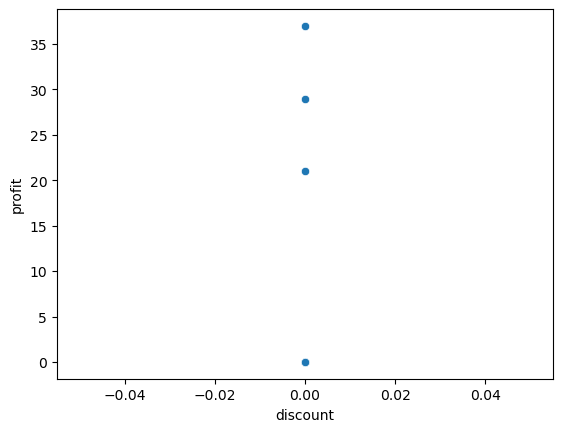

In [15]:
sns.scatterplot(x='discount', y='profit', data=df_orders)

#  Discount vs Profit Insights

- The majority of transactions occur at very low or zero discount levels.
- Profit shows significant variation even at minimal discount, indicating that factors other than discount (such as product type or cost structure) influence profitability.
- No strong linear relationship between discount and profit is observed in the current data distribution.

#  Recommendation

- Since discount variation is limited, further analysis should include product-level or category-level segmentation to better understand profit drivers.
- Evaluate whether discount strategies are underutilized or not effectively influencing sales.

## SALES DISTRIBUTION

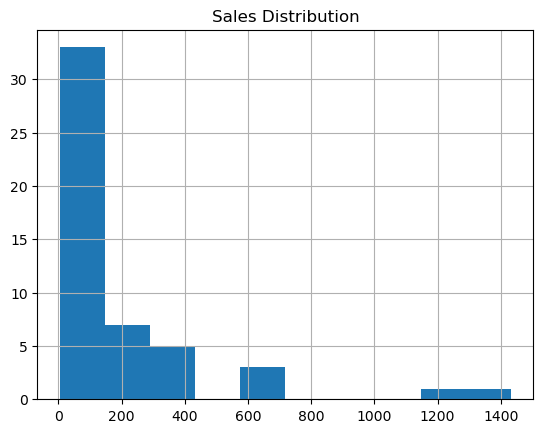

In [16]:
df_orders['sales'].hist()
plt.title("Sales Distribution")
plt.show()

- Sales are highly right-skewed, with most transactions in the lower range and a few high-value orders.
- A small number of high-value transactions contribute significantly to total revenue.

## PROFIT DISTRIBUTION

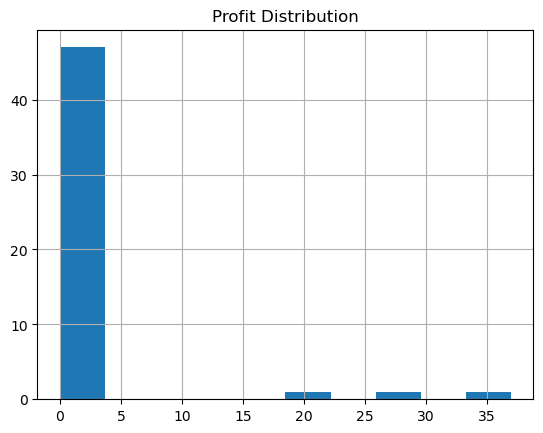

In [17]:
df_orders['profit'].hist()
plt.title("Profit Distribution")
plt.show()

- Profit is concentrated near zero, indicating many low-margin transactions.
- Only a few transactions generate significant profit, suggesting uneven profitability.

## SALES vs PROFIT

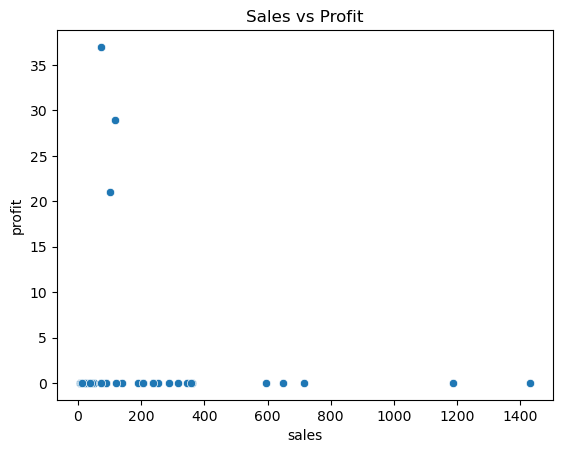

In [18]:
sns.scatterplot(x='sales', y='profit', data=df_orders)
plt.title("Sales vs Profit")
plt.show()

- High sales do not necessarily translate into high profit.
- Several high-sales transactions generate little or no profit, indicating potential pricing or cost inefficiencies.
- Profitability is inconsistent across transactions.

## TOP 10 ORDERS

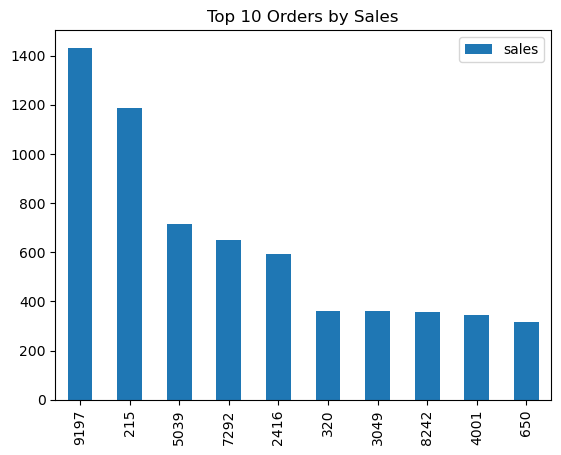

In [19]:
top_orders = df_orders.sort_values(by='sales', ascending=False).head(10)

top_orders[['order_id','sales']].plot(kind='bar')
plt.title("Top 10 Orders by Sales")
plt.show()

- Revenue is highly concentrated among a small number of high-value orders.
- The top few transactions contribute disproportionately to total sales.

### Orders Analysis Summary

- Sales distribution is highly skewed, with most transactions being low-value and a few high-value outliers.
- Profit distribution indicates that most transactions generate minimal profit, with only a few high-profit cases.
- There is no strong relationship between sales and profit, highlighting inefficiencies in pricing or cost structure.
- A small number of orders contribute significantly to overall revenue, indicating revenue concentration risk.

### Recommendations

- Improve pricing strategy to ensure high sales also result in higher profit.
- Identify and reduce loss-making or low-margin transactions.
- Focus on increasing mid-range sales instead of relying heavily on a few high-value orders.
- Analyze cost structure for high-sales but low-profit orders.

## PRODUCT ANALYSIS

In [22]:
df_prod = df_orders.merge(df_products, on='product_id', how='left')

df_prod.groupby('category')['sales'].sum()

category
Furniture           428.0
Office Supplies     505.0
Technology         8436.0
Name: sales, dtype: float64

In [23]:
df_prod.head()

,row_id,order_id,order_date,ship_date,ship_mode,customer_id,segment,postal_code,product_id,sales,quantity,discount,profit,month,category,sub-category,product_name
0,216,CA-2021-146262,2021-02-01,09/01/2021,Standard Class,VW-21775,Corporate,44256,TEC-MA-10000864,1188.0,9,0.0,0.0,2,Technology,Machines,Cisco 9971 IP Video Phone Charcoal
1,321,CA-2020-164973,2020-04-11,09/11/2020,Standard Class,NM-18445,Home Office,10024,TEC-AC-10000892,360.0,4,0.0,0.0,4,Technology,Accessories,NETGEAR N750 Dual Band Wi-Fi Gigabit Router
2,651,CA-2022-160745,2022-11-12,16/12/2022,Second Class,AR-10825,Corporate,98661,TEC-AC-10001142,316.0,4,0.0,0.0,11,Technology,Accessories,First Data FD10 PIN Pad
3,783,US-2021-157014,2021-03-10,06/10/2021,Second Class,BM-11785,Consumer,43229,TEC-AC-10002167,24.0,2,0.0,0.0,3,Technology,Accessories,Imation8gb Micro Traveldrive Usb 2.0Flash Drive
4,1624,CA-2023-108560,2023-08-07,15/07/2023,Standard Class,JC-15385,Consumer,98031,TEC-AC-10003063,50.0,2,0.0,0.0,8,Technology,Accessories,Micro Innovations USB RF Wireless Keyboard wit...


In [24]:

df_prod.columns

Index(['row_id', 'order_id', 'order_date', 'ship_date', 'ship_mode',
       'customer_id', 'segment', 'postal_code', 'product_id', 'sales',
       'quantity', 'discount', 'profit', 'month', 'category', 'sub-category',
       'product_name'],
      dtype='object')

In [25]:
print(df_prod.columns)

Index(['row_id', 'order_id', 'order_date', 'ship_date', 'ship_mode',
       'customer_id', 'segment', 'postal_code', 'product_id', 'sales',
       'quantity', 'discount', 'profit', 'month', 'category', 'sub-category',
       'product_name'],
      dtype='object')


In [26]:
df_prod.columns = df_prod.columns.str.replace('-', '_')

## Sales by Category

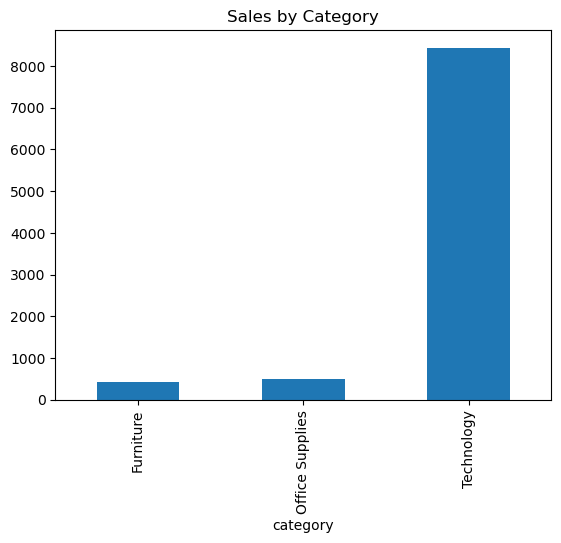

In [27]:
category_sales = df_prod.groupby('category')['sales'].sum().sort_values()

category_sales.plot(kind='bar')
plt.title("Sales by Category")
plt.show()

- Technology category is the primary revenue driver, contributing the majority of total sales.
- Furniture and Office Supplies contribute significantly less, indicating imbalance in category performance.

## Profit by Category

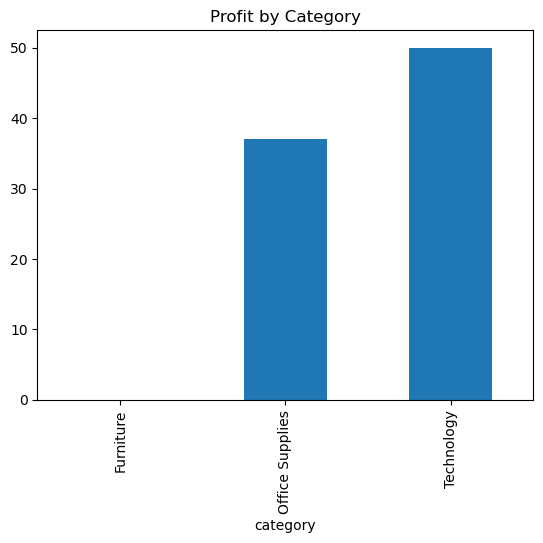

In [28]:
category_profit = df_prod.groupby('category')['profit'].sum().sort_values()

category_profit.plot(kind='bar')
plt.title("Profit by Category")
plt.show()

- Office Supplies is the most efficient category in terms of profit margin.
- Technology generates high revenue but operates at lower margins.
- Furniture shows extremely low or near-zero margin, indicating poor profitability.

## Sales & Profit by Sub-category

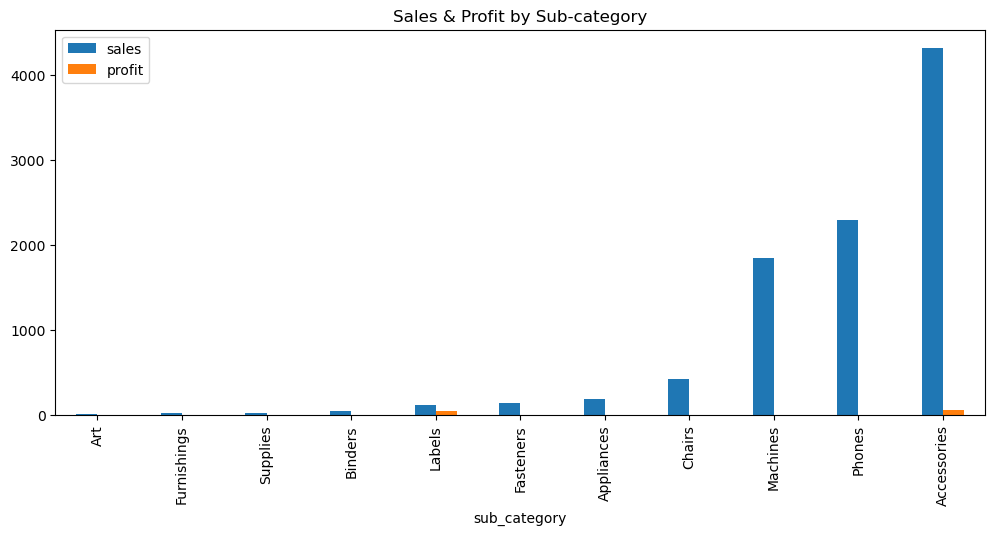

In [29]:
subcat = df_prod.groupby('sub_category')[['sales','profit']].sum().sort_values(by='sales')

subcat.plot(kind='bar', figsize=(12,5))
plt.title("Sales & Profit by Sub-category")
plt.show()

- Accessories, Phones, and Machines are the top-performing sub-categories in terms of sales.
- Several sub-categories generate significant sales but negligible profit.
- Indicates serious pricing or cost inefficiencies at sub-category level.

## Average Profit Margin by Category

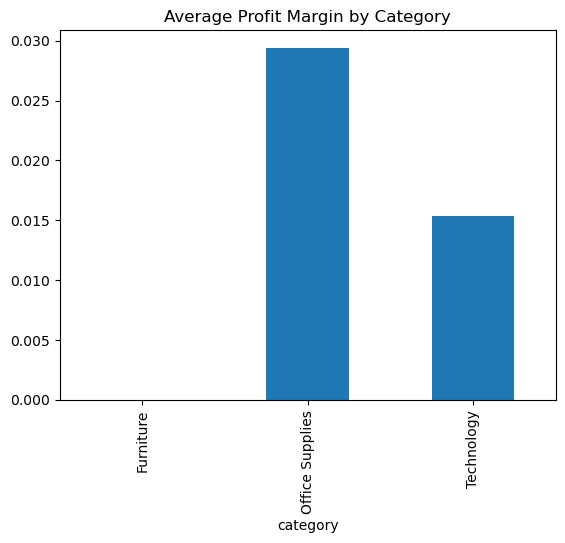

In [30]:
df_prod['profit_margin'] = df_prod['profit'] / df_prod['sales']

margin = df_prod.groupby('category')['profit_margin'].mean()

margin.plot(kind='bar')
plt.title("Average Profit Margin by Category")
plt.show()

- Revenue is highly concentrated in a few top-performing products.
- Dependency on limited products increases business risk.

## Top Products by Sales

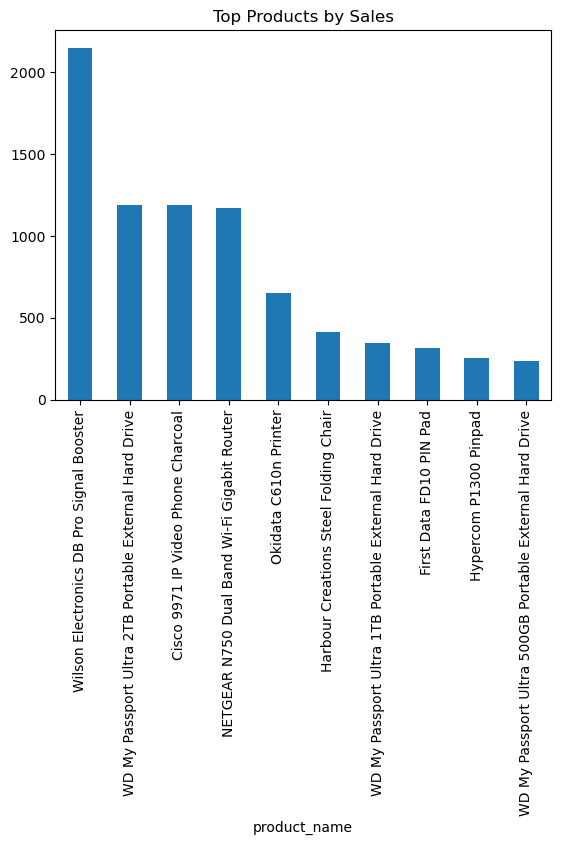

In [31]:
top_products = df_prod.groupby('product_name')['sales'].sum().sort_values(ascending=False).head(10)
top_products.plot(kind='bar')
plt.title("Top Products by Sales")
plt.show()

# Top Products Analysis

- Sales are highly concentrated among a few top-performing products.
- The leading product significantly outperforms all others, indicating strong demand or market preference.
- There is a sharp decline in sales after the top 4–5 products, showing uneven product performance.
- Majority of products contribute relatively low sales compared to top performers.

## Sales vs Profit by Category

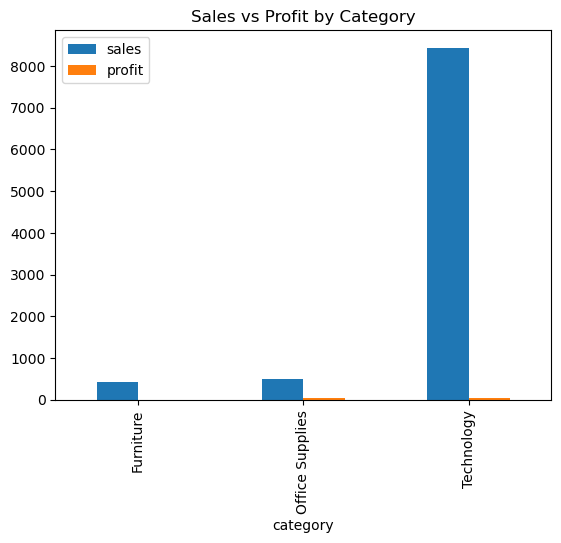

In [32]:
cat = df_prod.groupby('category')[['sales','profit']].sum()

cat.plot(kind='bar')
plt.title("Sales vs Profit by Category")
plt.show()

### Category Performance Insights

- Technology dominates overall sales, contributing the highest revenue among all categories.
- Despite high sales, Technology shows relatively low profit, indicating margin inefficiencies.
- Office Supplies generates moderate sales with comparatively better profit efficiency.
- Furniture performs poorly in both sales and profit, making it the weakest category.
- There is a clear imbalance between revenue generation and profitability across categories.

### Recommendations

- Improve pricing and cost structure in Technology category to increase profit margins.
- Focus on scaling Office Supplies due to better efficiency in generating profit.
- Re-evaluate Furniture category performance and optimize or reduce investment.
- Reduce dependency on revenue-heavy but low-margin categories.

## Recommendations
-Improve profit in Technology by fixing pricing and reducing discounts.

-Focus more on high-margin categories like Office Supplies.

-Fix or remove products that give low or negative profit.

-Balance focus on both sales and profit, not just revenue.

-Reduce dependency on a few top products by improving others.

-Learn from top-performing products and improve weaker ones.

# CUSTOMER ANALYSIS

In [33]:
df_cust = df_orders.merge(df_customers, on='customer_id', how='left')

df_cust.groupby('customer_name')['sales'].sum().sort_values(ascending=False).head(10)

customer_name
Greg Matthias        1432.0
Victoria Wilson      1188.0
Todd Sumrall          716.0
Lena Radford          649.0
Michelle Lonsdale     595.0
Tony Chapman          360.0
Nathan Mautz          360.0
Lena Hernandez        357.0
Dean percer           345.0
Anthony Rawles        316.0
Name: sales, dtype: float64

In [34]:
total_customers = df_cust['customer_id'].nunique()
total_orders = df_cust['order_id'].nunique()
avg_sales_per_customer = df_cust.groupby('customer_id')['sales'].sum().mean()

print(total_customers, total_orders, avg_sales_per_customer)

48 50 195.1875


## TOP 10 CUSTOMERS

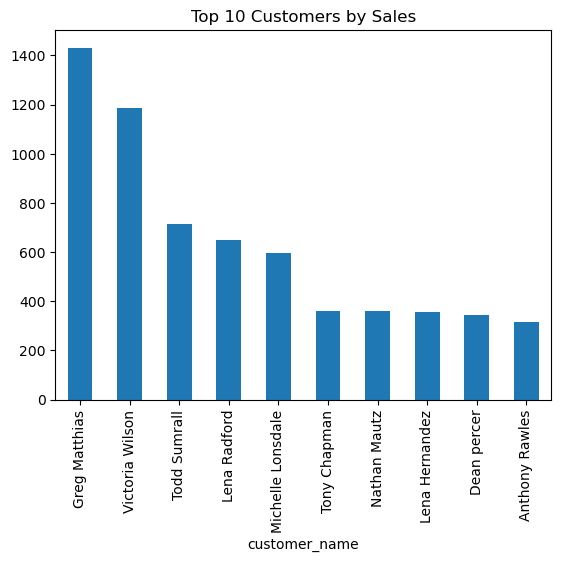

In [35]:
top_customers = df_cust.groupby('customer_name')[['sales','profit','order_id']].agg({
    'sales':'sum',
    'profit':'sum',
    'order_id':'count'
}).sort_values(by='sales', ascending=False).head(10)

top_customers['sales'].plot(kind='bar')
plt.title("Top 10 Customers by Sales")
plt.show()

- A small group of customers contributes a significant portion of total sales.
- Revenue is highly concentrated among top customers.

## CUSTOMER ORDER DISTRIBUTION

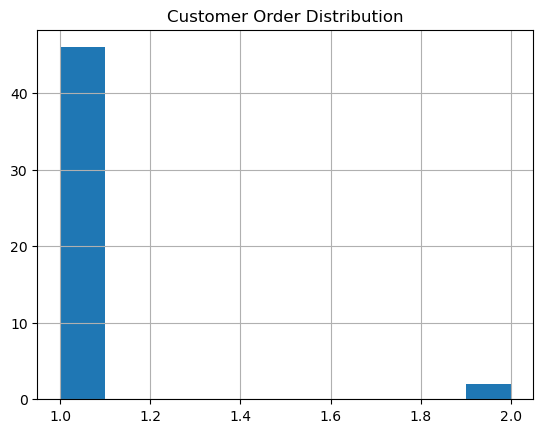

In [36]:
orders_per_customer = df_cust.groupby('customer_id')['order_id'].count()

orders_per_customer.hist()
plt.title("Customer Order Distribution")
plt.show()

- Majority of customers place only one order, showing low engagement.
- Very few customers make repeat purchases.

## CUSTOMER SEGMENT ANALYSIS

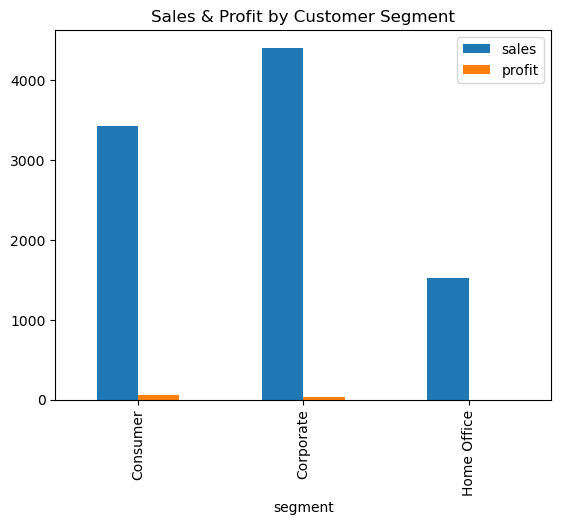

In [37]:
segment = df_cust.groupby('segment')[['sales','profit']].sum()

segment.plot(kind='bar')
plt.title("Sales & Profit by Customer Segment")
plt.show()

- Corporate segment generates the highest sales but does not translate proportionally into profit.
- Consumer segment shows better balance between sales and profit.
- Home Office contributes the least, indicating lower overall business impact.

## CUSTOMER VALUE ANALYSIS

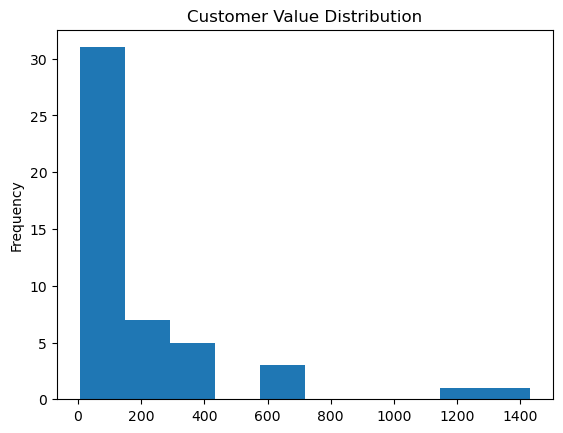

In [38]:
customer_value = df_cust.groupby('customer_id')['sales'].sum()

customer_value.plot(kind='hist')
plt.title("Customer Value Distribution")
plt.show()

- Most customers generate low revenue, while a few high-value customers drive overall sales.
- Customer value is highly skewed, indicating unequal contribution.

## TOP CUSTOMERS BY PROFIT

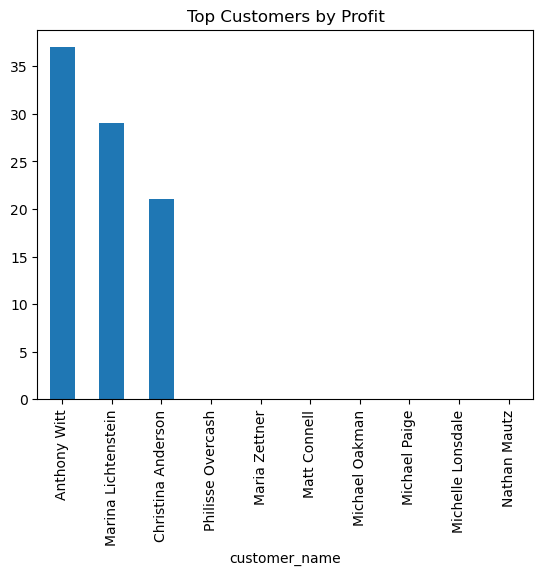

In [39]:
top_profit_customers = df_cust.groupby('customer_name')['profit'].sum().sort_values(ascending=False).head(10)

top_profit_customers.plot(kind='bar')
plt.title("Top Customers by Profit")
plt.show()

- A small number of customers contribute the majority of total profit.
- Profit generation is highly concentrated among a few high-value customers.

## Recommendations

- Improve profit by reducing discounts and fixing pricing.
- Focus more on high-profit products instead of just high sales.
- Reduce dependency on a few products and customers.
- Retain top customers with offers and loyalty programs.
- Increase repeat purchases from low-engagement customers.
- Improve performance of weak categories and segments.

# LOCATION ANALYSIS

In [40]:
df_loc = df_orders.merge(df_location, on='postal_code', how='left')

df_loc.groupby('region')['sales'].sum()

region
Central      78.0
East       3933.0
South      1718.0
West       3645.0
Name: sales, dtype: float64

## SALES BY REGION

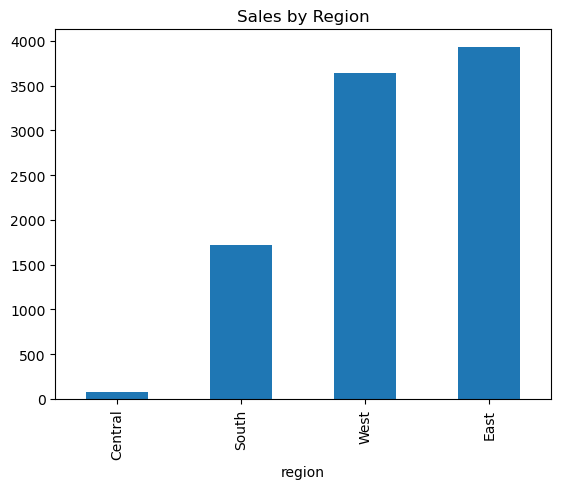

In [41]:
region_sales = df_loc.groupby('region')['sales'].sum().sort_values()

region_sales.plot(kind='bar')
plt.title("Sales by Region")
plt.show()

- East and West dominate overall sales performance.
- Central region contributes very little to total sales.

## PROFIT BY REGION

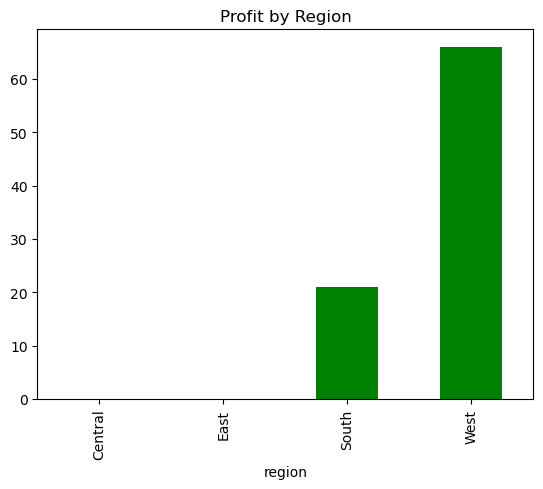

In [42]:
region_profit = df_loc.groupby('region')['profit'].sum().sort_values()

region_profit.plot(kind='bar', color='green')
plt.title("Profit by Region")
plt.show()

- West region generates the highest profit.
- Central and East regions show very low or no profit.

## SALES vs PROFIT

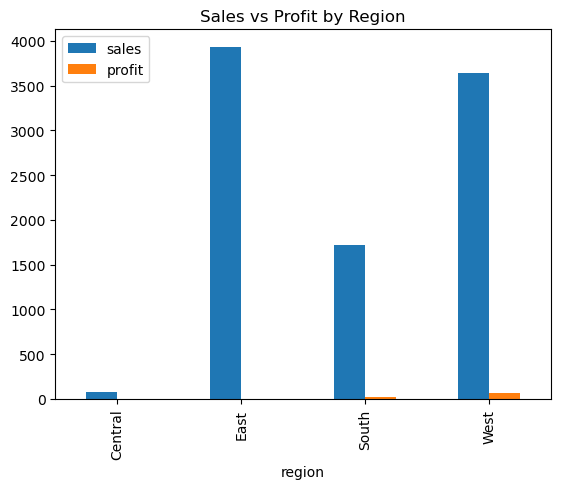

In [43]:
region = df_loc.groupby('region')[['sales','profit']].sum()

region.plot(kind='bar')
plt.title("Sales vs Profit by Region")
plt.show()

- East and West generate the highest sales.
- West shows better profit compared to other regions.

## TOP STATES

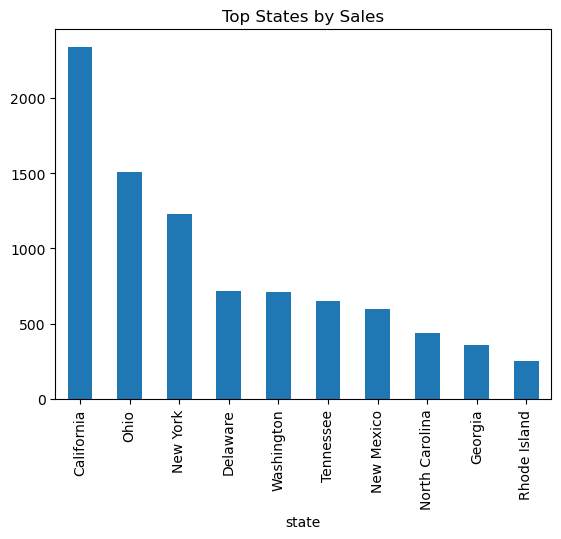

In [44]:
top_states = df_loc.groupby('state')['sales'].sum().sort_values(ascending=False).head(10)

top_states.plot(kind='bar')
plt.title("Top States by Sales")
plt.show()

- California, Ohio, and New York contribute the highest sales.
- Sales are concentrated in a few top-performing states.

## Recommendations
- Focus on improving performance in low-profit regions like Central.
- Invest more in high-performing regions like West and East.
- Optimize pricing and costs in regions with high sales but low profit.

# Final Conclusion

- Sales are driven mainly by Technology products, but profitability is low due to margin issues.
- A small number of products and customers contribute most of the revenue.
- Customer engagement is low, with most customers making only a few purchases.
- Business performance varies across regions, with West performing best and Central weakest.
- Overall, the business needs to focus on improving profitability, not just increasing sales.

#  Business Impact

- Identified key areas of revenue concentration and risk.
- Highlighted profit inefficiencies across products and regions.
- Provided actionable insights to improve customer engagement and retention.
- Suggested strategies to optimize product and pricing decisions.


This analysis helps in making data-driven decisions to improve sales performance, profitability, and overall business growth.